In [1]:
import pandas as pd

df = pd.read_csv('../data/user_data.csv')

df.head()

,user_id,signup_date,last_active_date,session_count,transactions_completed,onboarding_step,churned
0,1,2024-01-01,2024-01-05,5,2,5,No
1,2,2024-01-02,2024-01-03,2,0,2,Yes
2,3,2024-01-02,2024-01-10,8,4,5,No
3,4,2024-01-03,2024-01-04,1,0,1,Yes
4,5,2024-01-04,2024-01-08,6,3,5,No


In [2]:
df['churned'].value_counts()

churned
No     4
Yes    4
Name: count, dtype: int64

## Initial Insight 
A portion of users are churing early, indicating potential friction in onboarding or low engagement.

In [3]:
df['session_count'].describe()

count     8.00000
mean      4.62500
std       3.20435
min       1.00000
25%       2.00000
50%       4.00000
75%       6.50000
max      10.00000
Name: session_count, dtype: float64

In [4]:
df.groupby('churned')['session_count'].mean()

churned
No     7.25
Yes    2.00
Name: session_count, dtype: float64

## Engagement Insight
Users who churn have significantly lower session counts, indicating low engagement is strongly correlated to churn

In [5]:
df.groupby('churned')['transactions_completed'].mean()

churned
No     3.50
Yes    0.25
Name: transactions_completed, dtype: float64

## Transaction Insight
Users who complete more transactions are less likely to churn, suggesting that encouraging early transactions my improve retention 

In [6]:

df['onboarding_step'].value_counts ().sort_index()

onboarding_step
1    1
2    2
3    1
5    4
Name: count, dtype: int64

In [10]:
funnel = df['onboarding_step'].value_counts().sort_index()
funnel

onboarding_step
1    1
2    2
3    1
5    4
Name: count, dtype: int64

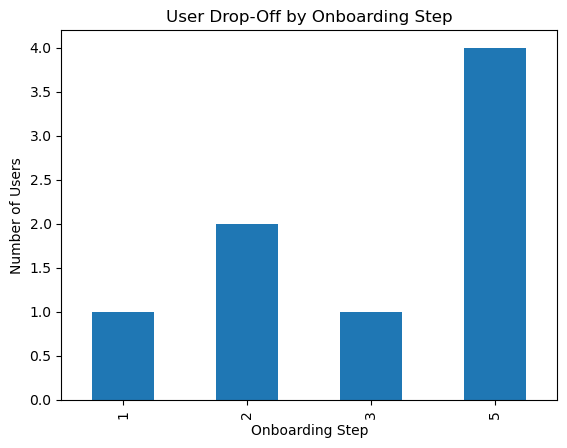

In [11]:
import matplotlib.pyplot as plt

funnel.plot(kind='bar')
plt.title("User Drop-Off by Onboarding Step")
plt.xlabel("Onboarding Step")
plt.ylabel("Number of Users")
plt.show()

## Onboarding Funnel Insight 
There is a noticable drop-off in users between onboarding steps 2 and 3. This suggests that users may be experiencing friction or confusion at this stage of the onboarding process. 

## Product Recommendations 
- Simplify the onboarding flow at the drop off step
- Reduce the number of required inputs or steps
- Add progress indicators or guidance to improve compeltion rates 
- Consider adding incentives for completing onboarding 